In [1]:
import pandas as pd

df = pd.read_csv("bank.csv", sep=";")

In [2]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [6]:
df["y"].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


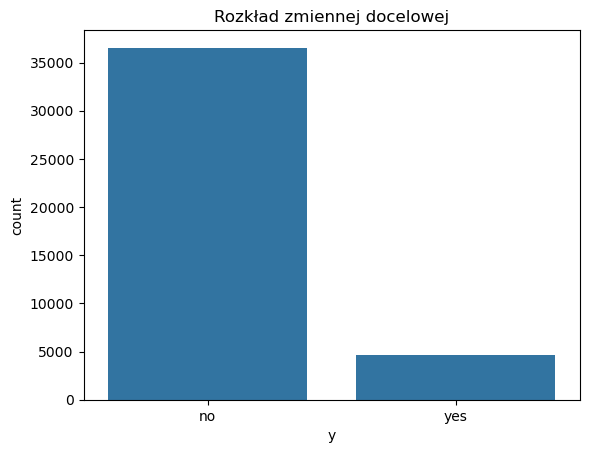

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="y", data=df)
plt.title("Rozkład zmiennej docelowej")
plt.show()

In [36]:
df.isin(["unknown"]).sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [37]:
import numpy as np

df = df.replace("unknown", np.nan)

In [38]:
df = df.fillna(df.mode().iloc[0])

In [39]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [40]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("y_yes", axis=1)
y = df_encoded["y_yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample"
)

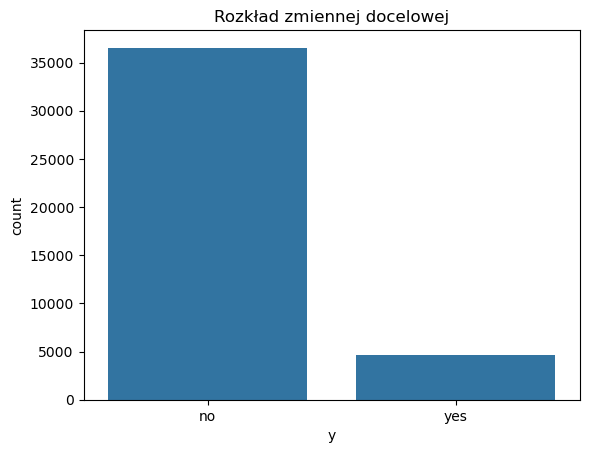

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="y", data=df)
plt.title("Rozkład zmiennej docelowej")
plt.show()

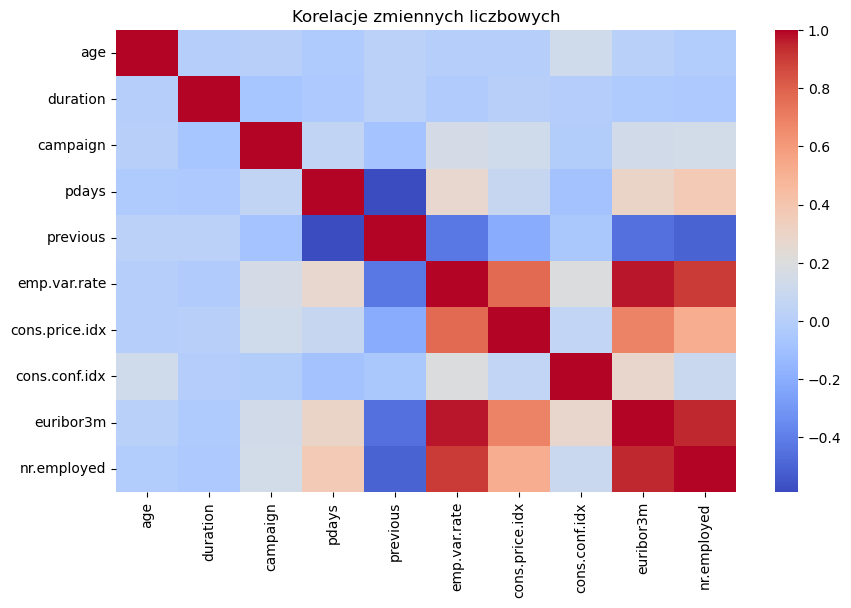

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm")
plt.title("Korelacje zmiennych liczbowych")
plt.show()

In [44]:
df = df.replace("unknown", np.nan)
df = df.fillna(df.mode().iloc[0])
df_encoded = pd.get_dummies(df, drop_first=True)

In [45]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("y_yes", axis=1)
y = df_encoded["y_yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_proba = rf.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.3).astype(int)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8945132313668366
              precision    recall  f1-score   support

       False       0.98      0.90      0.94      7310
        True       0.52      0.86      0.65       928

    accuracy                           0.89      8238
   macro avg       0.75      0.88      0.79      8238
weighted avg       0.93      0.89      0.91      8238

[[6567  743]
 [ 126  802]]


In [50]:
import pandas as pd

feat = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feat.head(10))

                        feature  importance
1                      duration    0.294129
8                     euribor3m    0.093282
9                   nr.employed    0.074364
7                 cons.conf.idx    0.058980
5                  emp.var.rate    0.045072
6                cons.price.idx    0.043108
0                           age    0.035182
27  education_university.degree    0.031959
3                         pdays    0.021416
20              marital_married    0.020261


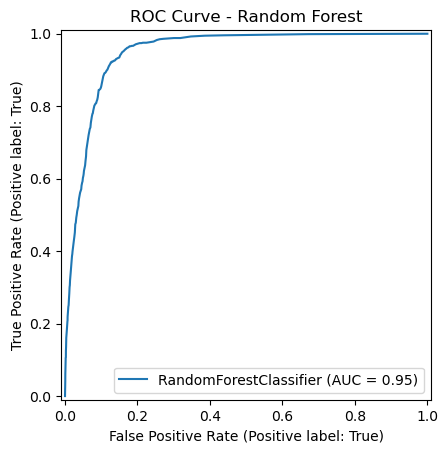

In [51]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

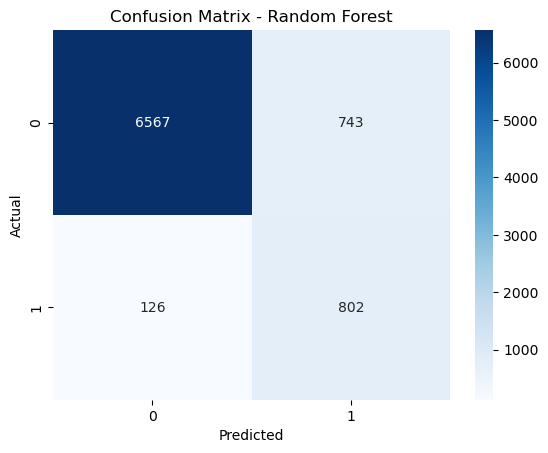

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

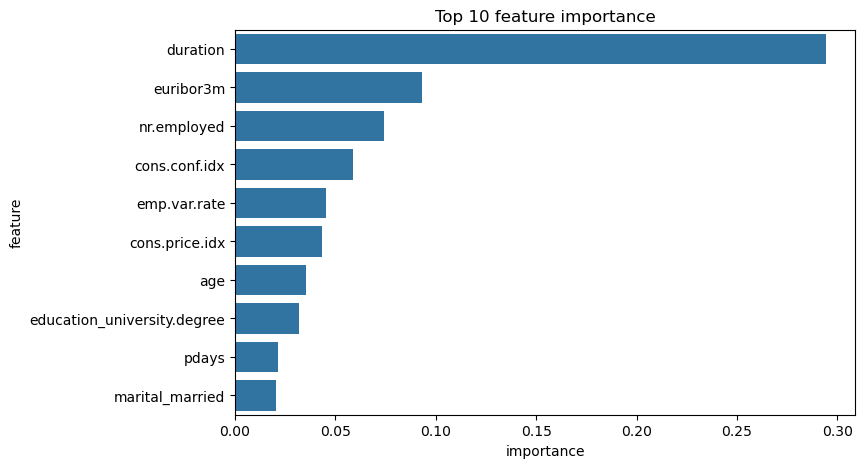

In [53]:
feat_top = feat.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=feat_top)
plt.title("Top 10 feature importance")
plt.show()

In [54]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

np.float64(0.9479344544553989)

In [26]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.4375

In [55]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.5190938511326861

In [56]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.8873512988589464

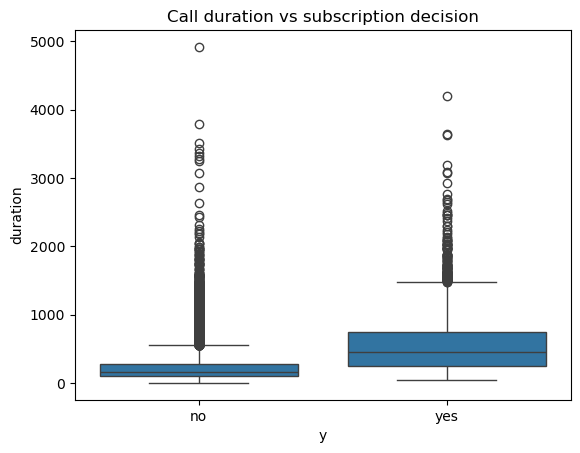

In [57]:
sns.boxplot(x="y", y="duration", data=df)
plt.title("Call duration vs subscription decision")
plt.show()

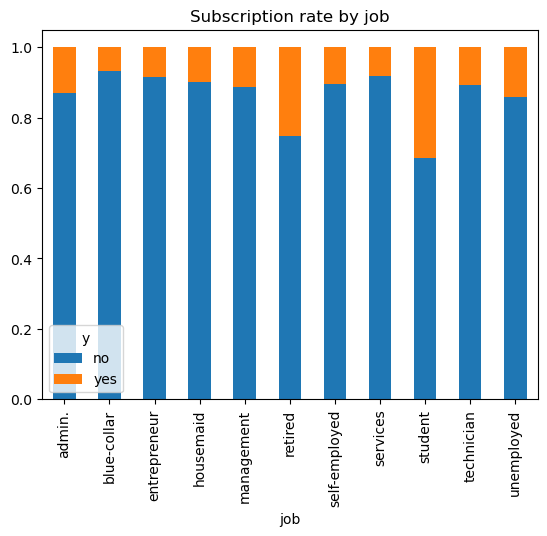

In [58]:
pd.crosstab(df["job"], df["y"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Subscription rate by job")
plt.show()

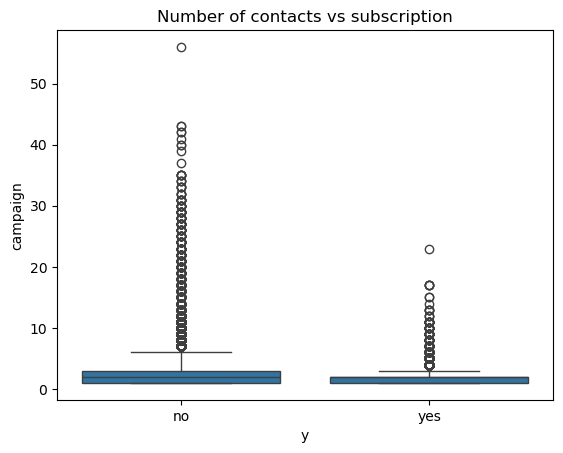

In [59]:
sns.boxplot(x="y", y="campaign", data=df)
plt.title("Number of contacts vs subscription")
plt.show()

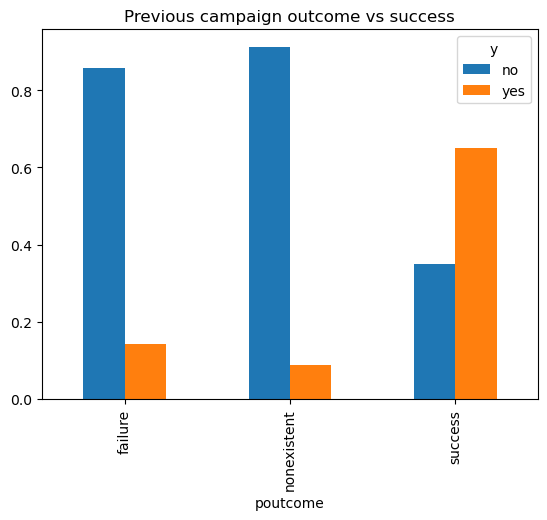

In [60]:
pd.crosstab(df["poutcome"], df["y"], normalize="index").plot(kind="bar")
plt.title("Previous campaign outcome vs success")
plt.show()

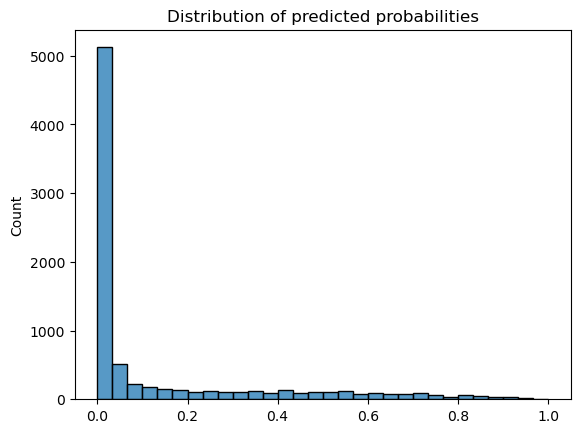

In [61]:
sns.histplot(y_proba, bins=30)
plt.title("Distribution of predicted probabilities")
plt.show()

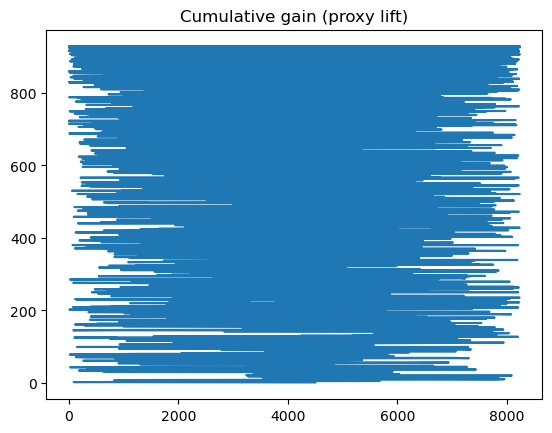

In [62]:
df_lift = pd.DataFrame({
    "prob": y_proba,
    "actual": y_test.values
}).sort_values("prob", ascending=False)

df_lift["cumulative_yes"] = df_lift["actual"].cumsum()

df_lift["cumulative_yes"].plot()
plt.title("Cumulative gain (proxy lift)")
plt.show()

In [63]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print(scores)
print("Mean AUC:", scores.mean())

[0.26189951 0.14237729 0.11864033 0.0716109  0.56527085]
Mean AUC: 0.23195977776867371


In [64]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_proba)
print("PR-AUC:", ap)

PR-AUC: 0.666734623505463


In [65]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_proba > t).astype(int)
    print(t)
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("-"*20)

0.2
Recall: 0.9299568965517241
Precision: 0.45637228979375993
--------------------
0.3
Recall: 0.8642241379310345
Precision: 0.5190938511326861
--------------------
0.4
Recall: 0.7607758620689655
Precision: 0.5721231766612642
--------------------
0.5
Recall: 0.6023706896551724
Precision: 0.6076086956521739
--------------------


In [66]:
feat.sort_values("importance", ascending=False).head(15)

,feature,importance
1,duration,0.294129
8,euribor3m,0.093282
9,nr.employed,0.074364
7,cons.conf.idx,0.058980
5,emp.var.rate,0.045072
6,cons.price.idx,0.043108
0,age,0.035182
27,education_university.degree,0.031959
3,pdays,0.021416
20,marital_married,0.020261


In [67]:
feat["importance"].head(5).sum()

np.float64(0.5658271576664752)

In [68]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum()

print(cm_norm)

[[0.84352998 0.04382132]
 [0.04479243 0.06785628]]
